In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# Load Ethiopia data
# Based on your file snippet, there are NO rows to skip!
df = pd.read_csv("../data/ethiopia.csv")

# Add Country column
df['Country'] = 'Ethiopia'

# Parse the YEAR and DOY into a single 'Date' column
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract Month for seasonal analysis
df['Month'] = df['Date'].dt.month

print("Success! Data loaded and dates parsed.")
df.head()

Success! Data loaded and dates parsed.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [2]:
# Replace the NASA -999 sentinel with NaN
df.replace(-999, np.nan, inplace=True)

# Check for and drop duplicates
dup_count = df.duplicated().sum()
print(f"Duplicates found and removed: {dup_count}")
df.drop_duplicates(inplace=True)

# Missing value report
missing_report = df.isna().sum()
print("\nMissing values per column:\n", missing_report)

# Forward-fill small gaps (standard for meteorological time-series)
df.ffill(inplace=True)

Duplicates found and removed: 0

Missing values per column:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64


In [ ]:
# Summary Statistics
print("\nSummary Statistics:\n", df.describe())

# Outlier Detection (Z-Score > 3)
cols_to_check = ['T2M', 'PRECTOTCORR', 'RH2M', 'WS2M']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))
print("\nOutlier count per column (|Z| > 3):\n", (z_scores > 3).sum())



Summary Statistics:
               YEAR          DOY         T2M      T2M_MAX      T2M_MIN  \
count  4108.000000  4108.000000  4108.00000  4108.000000  4108.000000   
mean   2020.131451   180.121227    16.06850    23.199175    10.227544   
min    2015.000000     1.000000    10.03000    15.650000     1.170000   
25%    2017.000000    86.000000    14.82000    21.110000     8.417500   
50%    2020.000000   179.000000    16.04000    22.740000    10.990000   
75%    2023.000000   272.000000    17.36000    25.170000    12.220000   
max    2026.000000   366.000000    21.53000    30.930000    15.680000   
std       3.248907   106.294767     1.89805     2.751471     2.607256   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean     12.971631     3.633795    68.408588     1.979998     3.575246   
min       3.560000     0.000000    14.420000     0.460000     0.790000   
25%       9.830000     0

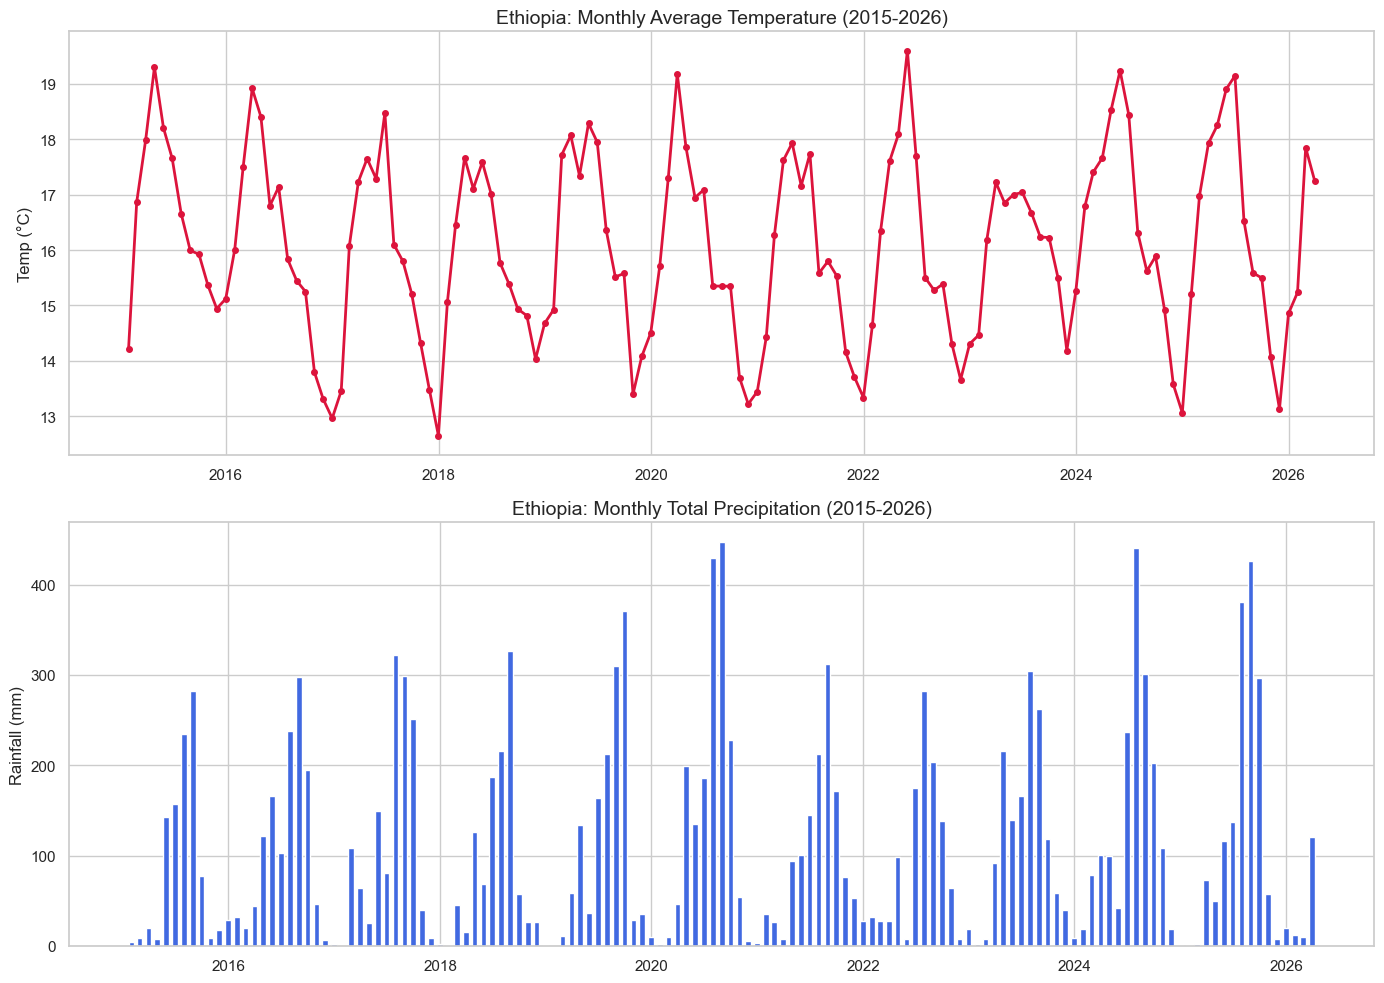

In [9]:
# Set up the style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Monthly Average Temperature (T2M)
# Changed 'M' to 'ME' for newer Pandas versions
monthly_t2m = df.resample('ME', on='Date')['T2M'].mean()
ax1.plot(monthly_t2m.index, monthly_t2m.values, color='crimson', linewidth=2, marker='o', markersize=4)
ax1.set_title('Ethiopia: Monthly Average Temperature (2015-2026)', fontsize=14)
ax1.set_ylabel('Temp (°C)')

# Plot 2: Monthly Total Precipitation
# Changed 'M' to 'ME' here as well
monthly_precip = df.resample('ME', on='Date')['PRECTOTCORR'].sum()
ax2.bar(monthly_precip.index, monthly_precip.values, color='royalblue', width=20)
ax2.set_title('Ethiopia: Monthly Total Precipitation (2015-2026)', fontsize=14)
ax2.set_ylabel('Rainfall (mm)')

plt.tight_layout()
plt.show()

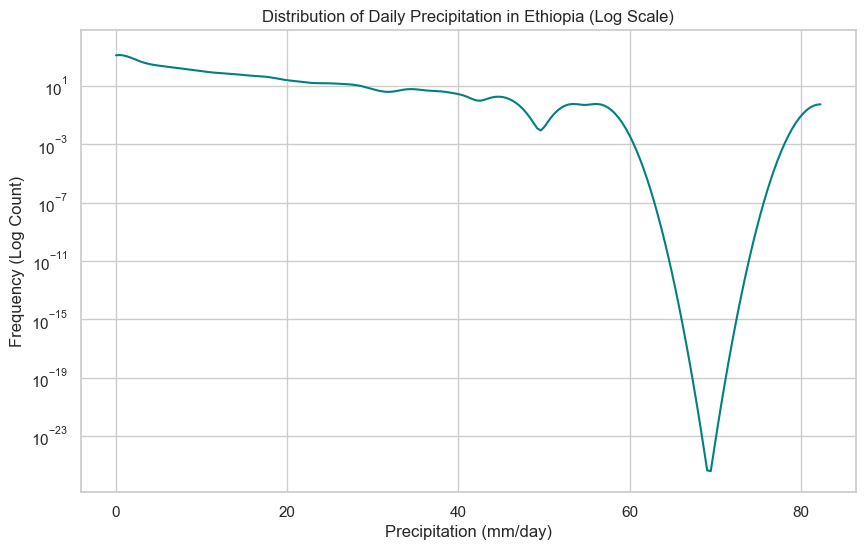

In [10]:
plt.figure(figsize=(10, 6))
# Histogram of Rainfall with a Log scale because most days have 0 rain
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, log_scale=(False, True), color='teal')
plt.title('Distribution of Daily Precipitation in Ethiopia (Log Scale)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (Log Count)')
plt.show()